In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Preparação do Dataset

⚠️ Reshape porque implementaremos a MLP usando operações matriciais. 

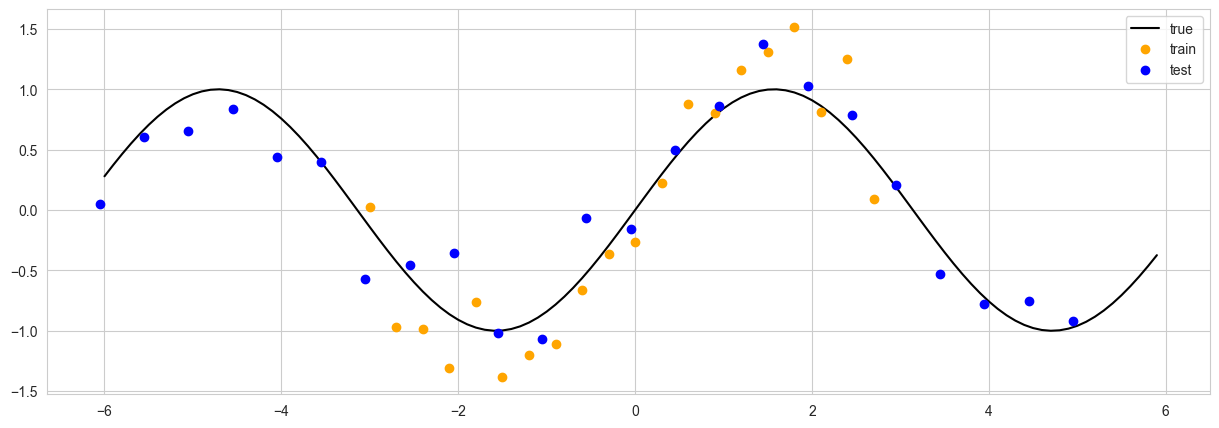

In [3]:
all_x = np.arange(-6.0, 6.0, 0.1)
train_x = np.arange(-3, 3, 0.3)
test_x = np.arange(-6.05, 5.06, 0.5)

all_x = all_x.reshape((len(all_x), 1, 1))
train_x = train_x.reshape((len(train_x), 1, 1))
test_x = test_x.reshape((len(test_x), 1, 1))

train_y = np.sin(train_x) + np.random.normal(size=train_x.shape) * 0.3
test_y = np.sin(test_x) + np.random.normal(size=test_x.shape) * 0.3

plt.close('all')
plt.figure(figsize=(15,5))
plt.plot(all_x.squeeze(), np.sin(all_x).squeeze(), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(test_x.squeeze(), test_y.squeeze(), 'o', color='blue', label='test')
plt.legend()
plt.show()

## Implementação da MLP - Versão mais Simples

### Funções de Ativação e Suas Derivadas

In [4]:
import numpy as np

def sigmoid(x):
    """
    Função sigmoid: sigma(x) = 1 / (1 + exp(-x))
    Pode ser usada com escalares, vetores ou matrizes NumPy.
    """
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh_grad(x):
    return 1 - np.square(np.tanh(x))

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(x.dtype)

### MLP


In [5]:

class Mlp:
    def __init__(self, activation_fn, activation_grad_fn, n_hidden):
        self._activation_fn = activation_fn
        self._activation_grad_fn = activation_grad_fn
        self._n_hidden = n_hidden
        self.reset()

    def reset(self):
        """Reinicia os parametros para valores aleatorios"""
        mult = 1
        self._w0 = mult * np.random.normal(size=(self._n_hidden, 1))
        self._b0 = mult * np.random.normal(size=(self._n_hidden, 1))
        self._w1 = mult * np.random.normal(size=(1, self._n_hidden))
        self._b1 = mult * np.random.normal(size=(1, 1))

    def zero_grad(self):
        """Reseta os gradientes para zero"""
        self._grad_w0 = np.zeros_like(self._w0)
        self._grad_b0 = np.zeros_like(self._b0)
        self._grad_w1 = np.zeros_like(self._w1)
        self._grad_b1 = np.zeros_like(self._b1)

    def forward(self, x):
        """Calcula a saida da rede para uma dada entrada"""
        # first layer
        self._z0 = np.matmul(self._w0, x) + self._b0
        self._h0 = self._activation_fn(self._z0)

        # second layer
        self._z1 = np.matmul(self._w1, self._h0) + self._b1
        self._y = self._z1 # without activation_fn because we are doing regression

        return self._y

    def backward(self, x_i, y_i_hat, N):
        """Adiciona a contribuicao da amostra (x, y_hat) nos gradientes"""
        # Derivada do erro em relacao a saida da rede
        #
        # Nota: Vamos fazer a divisão (1 / N) a cada amotra ao inves de fazer depois de
        # somar todos os gradientes para alcançar uma maior estabilidade numérica
        # (evitar que a soma dos gradientes fiquem muito grandes e alcancem os limites
        # da representação de pontos flutuantes)
        #
        dloss_dy = (1 / N) * 2 * (self._y[0, 0] - y_i_hat[0, 0])


        # derivada do erro em relacao aos pesos da ultima camada
        for k in range(self._n_hidden):
            self._grad_w1[0, k] += dloss_dy * self._h0[k, 0]

        # derivada do erro em relacao ao bias da ultima camada
        self._grad_b1[0, 0] += dloss_dy

        for k in range(self._n_hidden):
            dloss_dz0_k = dloss_dy * \
                self._w1[0, k] * \
                self._activation_grad_fn(self._z0[k, 0])

            # derivada do erro em relacao aos pesos da camada oculta
            self._grad_w0[k, 0] += dloss_dz0_k * x_i[0, 0]

            # derivada do erro em relacao aos biases da camada oculta
            self._grad_b0[k, 0] += dloss_dz0_k

    def update(self, lr):
        """Realiza um passo de gradient descent"""
        self._w0 -= lr * self._grad_w0
        self._b0 -= lr * self._grad_b0
        self._w1 -= lr * self._grad_w1
        self._b1 -= lr * self._grad_b1

mlp = Mlp(np.tanh, tanh_grad, 10)
mlp

### Experimentos

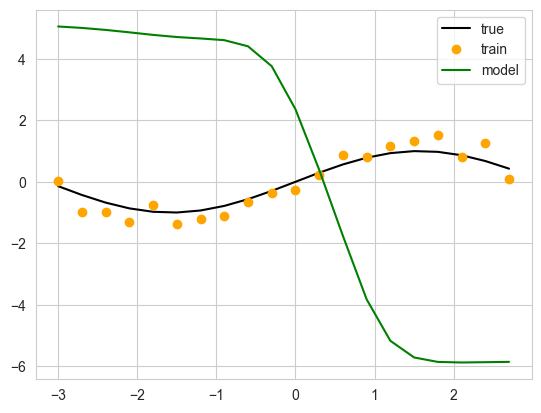

In [6]:
preds = [mlp.forward(x_i).squeeze() for x_i in train_x]


plt.close('all')
plt.plot(train_x.squeeze(), np.sin(train_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(train_x.squeeze(), preds, '-', color='green', label='model')
plt.legend()
plt.show()

100%|██████████| 2000/2000 [00:02<00:00, 713.78it/s]


loss nas primeiras epocas: [np.float64(4.080942435592858), np.float64(2.7150345311402275), np.float64(2.245994549833985), np.float64(1.982011388265158), np.float64(1.7748877751799612)]
loss nas ultimas epocas: [np.float64(0.05232863284914304), np.float64(0.05232941928746193), np.float64(0.05232088475922123), np.float64(0.052314186582956855), np.float64(0.052307754144173824)]


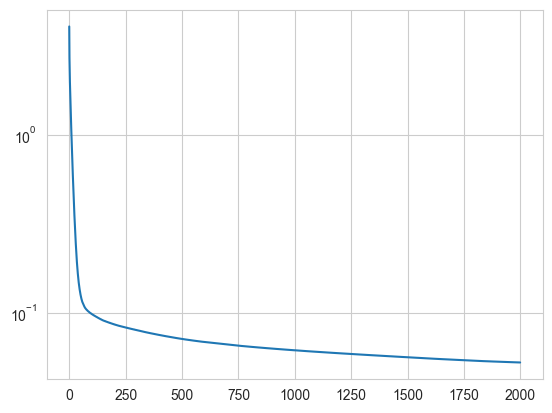

In [7]:
from tqdm import tqdm

# hiperparametros
history = []
lr = 0.01
n_epochs = 2000
n_hidden_neurons = 32
act_fn = relu
act_grad_fn = relu_grad
# act_fn = np.tanh
# act_grad_fn = tanh_grad

# restart the training from scratch
# if the cell is executed more than once
mlp = Mlp(act_fn, act_grad_fn, n_hidden_neurons)
mlp.reset()

for epoch in tqdm(range(n_epochs)):
    preds = []

    # reseta os gradientes para zero
    mlp.zero_grad()

    for x_i, y_i in zip(train_x, train_y):
        pred_y = mlp.forward(x_i)
        preds.append(pred_y)
        mlp.backward(x_i, y_i, len(train_x))

    mlp.update(lr=lr)

    if epoch % 1 == 0:
        preds = np.array(preds)
        assert preds.shape == train_y.shape
        error = np.mean(np.square(preds - train_y))
        history.append(error)

print("loss nas primeiras epocas:", history[:5])
print("loss nas ultimas epocas:", history[-5:])
plt.plot(history)
plt.yscale('log')


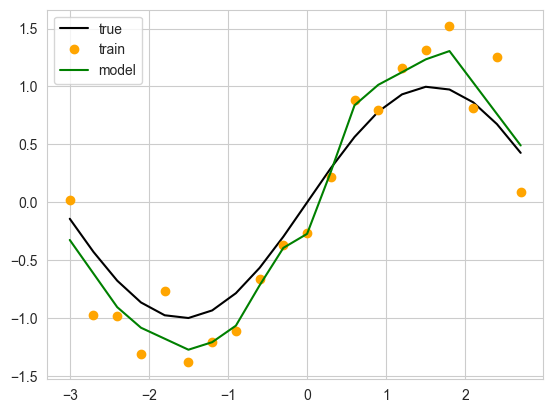

In [8]:
preds = np.array([mlp.forward(x) for x in train_x])


plt.close('all')
plt.plot(train_x.squeeze(), np.sin(train_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(train_x.squeeze(), preds.squeeze(), '-', color='green', label='model')
plt.legend()
plt.show()

In [9]:
preds = np.array([mlp.forward(np.array([[x]])) for x in train_x])
preds = preds.squeeze()

diffs = np.square(preds - train_y)
error = np.sum(diffs)
error

np.float64(707.7246534071517)

In [10]:
preds = np.array([mlp.forward(np.array([[x]])) for x in test_x])
preds = preds.squeeze()

diffs = np.square(preds - test_y)
error = np.sum(diffs)
error

np.float64(926.9966516378138)

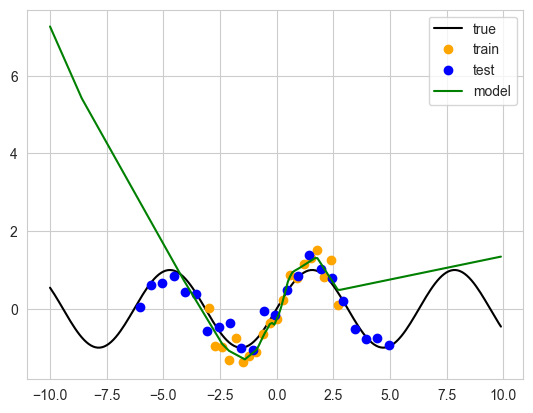

In [11]:
all_x = np.arange(-10.0, 10.0, 0.1)
all_x = all_x.reshape((len(all_x), 1, 1))

preds = np.array([mlp.forward(np.array(x)) for x in all_x])

plt.close('all')
plt.plot(all_x.squeeze(), np.sin(all_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(test_x.squeeze(), test_y.squeeze(), 'o', color='blue', label='test')
plt.plot(all_x.squeeze(), preds.squeeze(), '-', color='green', label='model')
plt.legend()
plt.show()

## Implementação da MLP - Versão Matricial

In [12]:

class MlpMatricial:
    def __init__(self, activation_fn, activation_grad_fn, n_hidden):
        self._activation_fn = activation_fn
        self._activation_grad_fn = activation_grad_fn
        self._n_hidden = n_hidden
        self.reset()
        self.zero_grad()

    def reset(self):
        self._w0 = np.random.normal(size=(self._n_hidden, 1))
        self._b0 = np.random.normal(size=(self._n_hidden, 1))
        self._w1 = np.random.normal(size=(1, self._n_hidden))
        self._b1 = np.random.normal(size=(1, 1))

    def zero_grad(self):
        self._grad_w0 = np.zeros_like(self._w0)
        self._grad_b0 = np.zeros_like(self._b0)
        self._grad_w1 = np.zeros_like(self._w1)
        self._grad_b1 = np.zeros_like(self._b1)

    def forward(self, x):
        # first layer
        self._z0 = np.matmul(self._w0, x) + self._b0
        self._h0 = self._activation_fn(self._z0)
        # second layer
        self._z1 = np.matmul(self._w1, self._h0) + self._b1
        self._y = self._z1 # without activation_fn

        return self._y

    def backward(self, x_i, y_i_hat, N):
        # d loss / d n1
        dloss_dy = (1 / N) * 2 * (self._y - y_i_hat)   # shape: [n_outs, 1]

        # gradient of last layer
        self._grad_w1 += dloss_dy @ self._h0.T  # shape: [n_outs, 1] x [1, n_hidden] = [n_outs, n_hidden]
        self._grad_b1 += dloss_dy   # shape: [n_outs, 1]

        # gradient of first layer
        dloss_dh = self._w1.T @ dloss_dy   # [n_hidden, n_outs] x [n_outs, 1] = [n_hidden, 1]
        dloss_dz0 = self._activation_grad_fn(self._z0) * dloss_dh    # [n_hidden, 1]
        dloss_dw0 = dloss_dz0 @ x_i.T  # # [n_hidden, 1] x [1, n_ins] = [n_hidden, n_ins]

        self._grad_w0 += dloss_dw0
        self._grad_b0 += dloss_dz0

    def update(self, lr):
        self._w0 -= lr * self._grad_w0
        self._b0 -= lr * self._grad_b0
        self._w1 -= lr * self._grad_w1
        self._b1 -= lr * self._grad_b1

mlp = MlpMatricial(relu, relu_grad, 2)
mlp

100%|██████████| 5000/5000 [00:01<00:00, 3330.32it/s]


loss nas primeiras epocas: [np.float64(584.6596526236711), np.float64(188.0041600388899), np.float64(72.63064056021732), np.float64(31.01852325916915), np.float64(14.635025717312729)]
loss nas ultimas epocas: [np.float64(2.0922934458162676), np.float64(2.0833326541788946), np.float64(2.0747325004969586), np.float64(2.0664741657851122), np.float64(2.058539864178376)]


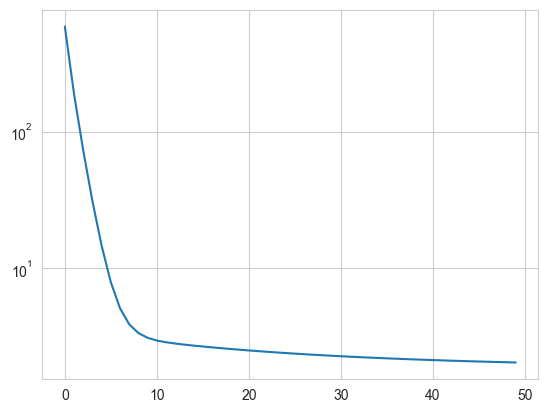

In [13]:
from tqdm import tqdm

# hiperparametros
history = []
lr = 1e-4
n_epochs = 5000
n_hidden_neurons = 32
act_fn = np.tanh
act_grad_fn = tanh_grad

# restart the training from scratch
# if the cell is executed more than once
mlp = MlpMatricial(act_fn, act_grad_fn, n_hidden_neurons)
mlp.reset()

for epoch in tqdm(range(n_epochs)):
    preds = []

    # reseta os gradientes para zero
    mlp.zero_grad()

    for x_i, y_i in zip(train_x, train_y):
        pred_y = mlp.forward(x_i)
        mlp.backward(x_i, y_i, len(train_x))
        preds.append(pred_y)

    mlp.update(lr=lr)

    if epoch % 100 == 0:
        preds = np.array(preds)
        assert preds.shape == train_y.shape
        error = np.sum(np.square(preds - train_y))
        history.append(error)

print("loss nas primeiras epocas:", history[:5])
print("loss nas ultimas epocas:", history[-5:])
plt.plot(history)
plt.yscale('log')


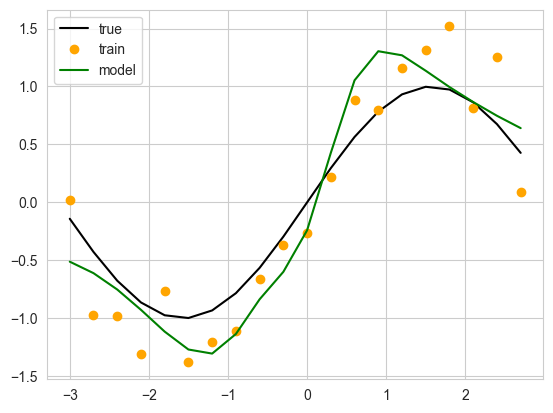

In [14]:
preds = np.array([mlp.forward(x) for x in train_x])


plt.close('all')
plt.plot(train_x.squeeze(), np.sin(train_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(train_x.squeeze(), preds.squeeze(), '-', color='green', label='model')
plt.legend()
plt.show()

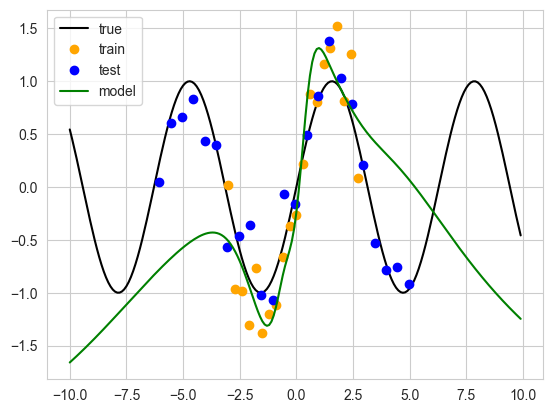

In [15]:
all_x = np.arange(-10.0, 10.0, 0.1)
all_x = all_x.reshape((len(all_x), 1, 1))

preds = np.array([mlp.forward(np.array(x)) for x in all_x])

plt.close('all')
plt.plot(all_x.squeeze(), np.sin(all_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(test_x.squeeze(), test_y.squeeze(), 'o', color='blue', label='test')
plt.plot(all_x.squeeze(), preds.squeeze(), '-', color='green', label='model')
plt.legend()
plt.show()

Diferença de Tempo com uso de Matricial ou Loop

In [16]:
from time import time

n_hidden_neurons = 64
mlp_loop = Mlp(act_fn, act_grad_fn, n_hidden_neurons)
mlp_mat = MlpMatricial(act_fn, act_grad_fn, n_hidden_neurons)

start = time()

for epoch in tqdm(range(100)):
    mlp_loop.zero_grad()
    for x_i, y_i in zip(train_x, train_y):
        pred_y = mlp_loop.forward(x_i)
        mlp_loop.backward(x_i, y_i, len(train_x))

dt_loop = time() - start
print("Tempo (loop): ", dt_loop)

start = time()

for epoch in tqdm(range(100)):
    mlp_mat.zero_grad()
    for x_i, y_i in zip(train_x, train_y):
        pred_y = mlp_mat.forward(x_i)
        mlp_mat.backward(x_i, y_i, len(train_x))

dt_mat = time() - start
print("Tempo (matrix): ", dt_mat)

print("Speed up:", dt_loop / dt_mat)

100%|██████████| 100/100 [00:00<00:00, 298.45it/s]


Tempo (loop):  0.33722376823425293


100%|██████████| 100/100 [00:00<00:00, 3346.02it/s]

Tempo (matrix):  0.03188586235046387
Speed up: 10.57596512610383


### Multilayer

In [17]:

from tqdm import tqdm

def identity(x):
    return x

def identity_grad(x):
    return 1


class MlpMultilayer:
    def __init__(self,
                activation_fn,
                activation_grad_fn,
                output_activation_fn,
                output_activation_grad_fn,
                loss_gradient_fn,
                sizes_layers: list[int]):
        self._activation_fn = activation_fn
        self._activation_grad_fn = activation_grad_fn
        self._output_activation_fn = output_activation_fn
        self._output_activation_grad_fn = output_activation_grad_fn
        self._sizes_layers = sizes_layers
        self._loss_gradient_fn = loss_gradient_fn
        self.reset()
        self.zero_grad()

    def reset(self):
        self._layers = []

        for i in range(len(self._sizes_layers) - 1):
            weights = np.random.normal(size=(self._sizes_layers[i + 1], self._sizes_layers[i]))
            bias = np.random.normal(size=(self._sizes_layers[i + 1], 1))
            self._layers.append([weights, bias])

    def zero_grad(self):
        self._grads = []
        for weights, bias in self._layers:
            self._grads.append([
                np.zeros_like(weights),
                np.zeros_like(bias),
            ])

    def forward(self, x):
        self._layer_outs = []

        layer_in = x

        for i, (weights, bias) in enumerate(self._layers):
            assert layer_in.size == self._sizes_layers[i], f"Expected input size for layer {i} is {self._sizes_layers[i]}, but given input is {layer_in.shape}"

            z = np.matmul(weights, layer_in) + bias

            if i < len(self._layers) - 1: # se nao for a ultima camada
                h = self._activation_fn(z)
            else:
                h = self._output_activation_fn(z)

            self._layer_outs.append([z, h])

            layer_in = h

        return layer_in


    def backward(self, x_i, y_i_hat, N):
        z_out, out = self._layer_outs[-1]

        dloss_dout = (1 / N) * self._loss_gradient_fn(out, y_i_hat)
        #print("dloss_dout:", dloss_dout.shape)

        # gradient of last layer
        _, layer_in = self._layer_outs[-2]
        dout_dz = self._output_activation_grad_fn(z_out)
        dloss_dz = dout_dz * dloss_dout
        #print("dloss_dz:", dloss_dz.shape)

        self._grads[-1][0] += dloss_dz @ layer_in.T  # shape: [n_outs, 1] x [1, n_hidden] = [n_outs, n_hidden]
        self._grads[-1][1] += dloss_dz   # shape: [n_outs, 1]

        dloss_dout = dloss_dz

        for i in range(len(self._layers) - 2, -1, -1):
            next_W, _ = self._layers[i + 1]
            z, _ = self._layer_outs[i]

            if i > 0:
                _, layer_in = self._layer_outs[i - 1]
            else:
                layer_in = x_i

            dloss_dh = next_W.T @ dloss_dout   # [n_hidden, n_outs] x [n_outs, 1] = [n_hidden, 1]
            dloss_dz = self._activation_grad_fn(z) * dloss_dh    # [n_hidden, 1]
            dloss_dw = dloss_dz @ layer_in.T  # # [n_hidden, 1] x [1, n_ins] = [n_hidden, n_ins]

            self._grads[i][0] += dloss_dw
            self._grads[i][1] += dloss_dz

            dloss_dout = dloss_dz


    def update(self, lr):
        for i in range(len(self._layers)):
            assert self._layers[i][0].shape == self._grads[i][0].shape
            assert self._layers[i][1].shape == self._grads[i][1].shape

            assert not np.isnan(self._grads[1][0]).any()
            assert not np.isnan(self._grads[1][1]).any()

            assert not np.isinf(self._grads[1][0]).any()
            assert not np.isinf(self._grads[1][1]).any()

            self._layers[i][0] -= lr * self._grads[i][0]
            self._layers[i][1] -= lr * self._grads[i][1]

            assert not np.isnan(self._layers[1][0]).any()
            assert not np.isnan(self._layers[1][1]).any()

            assert not np.isinf(self._layers[1][0]).any()
            assert not np.isinf(self._layers[1][1]).any()



100%|██████████| 10000/10000 [00:07<00:00, 1353.85it/s]


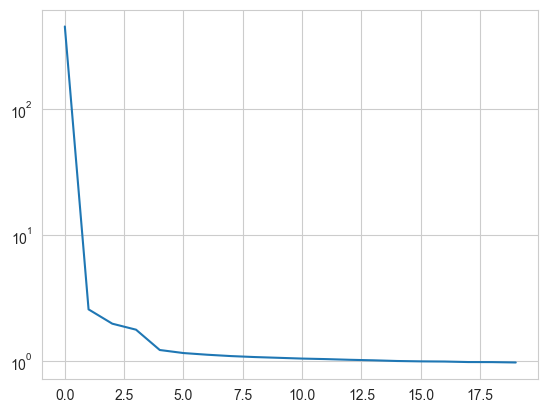

In [18]:

def mse_gradient_fn(y, y_hat):
    return 2 * (y - y_hat)


# hiperparametros
history = []
lr = 1e-3
n_epochs = 10000

# restart the training from scratch
# if the cell is executed more than once
mlp = MlpMultilayer(
    relu, relu_grad,
    identity, identity_grad,
    mse_gradient_fn,
    [1, 8, 8, 8, 1])

mlp.reset()

for epoch in tqdm(range(n_epochs)):
    preds = []

    # reseta os gradientes para zero
    mlp.zero_grad()

    for x_i, y_i in zip(train_x, train_y):
        pred_y = mlp.forward(x_i)
        mlp.backward(x_i, y_i, len(train_x))
        preds.append(pred_y)

    mlp.update(lr=lr)

    if epoch % (n_epochs // 20) == 0:
        preds = np.array(preds)
        assert preds.shape == train_y.shape
        error = np.sum(np.square(preds - train_y))
        history.append(error)

#print("loss nas primeiras epocas:", history[:3])
#print("loss nas ultimas epocas:", history[-3:])
plt.plot(history)
plt.yscale('log')


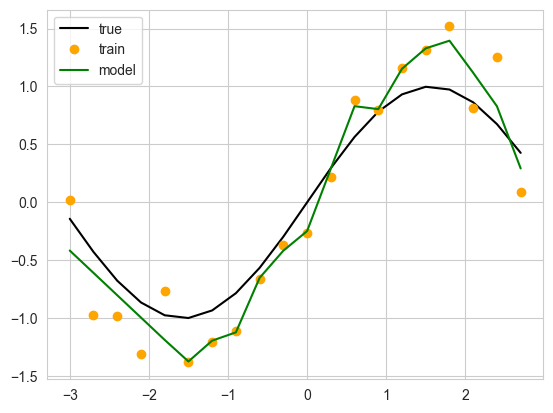

In [19]:
preds = np.array([mlp.forward(x) for x in train_x])


plt.close('all')
plt.plot(train_x.squeeze(), np.sin(train_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(train_x.squeeze(), preds.squeeze(), '-', color='green', label='model')
plt.legend()
plt.show()

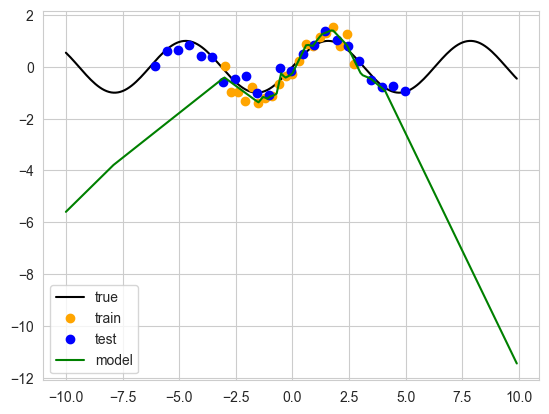

In [20]:
all_x = np.arange(-10.0, 10.0, 0.1)
all_x = all_x.reshape((len(all_x), 1, 1))

preds = np.array([mlp.forward(np.array(x)) for x in all_x])

plt.close('all')
plt.plot(all_x.squeeze(), np.sin(all_x.squeeze()), '-', color='black', label='true')
plt.plot(train_x.squeeze(), train_y.squeeze(), 'o', color='orange', label='train')
plt.plot(test_x.squeeze(), test_y.squeeze(), 'o', color='blue', label='test')
plt.plot(all_x.squeeze(), preds.squeeze(), '-', color='green', label='model')
plt.legend()
plt.show()